In [1]:
import extractor
import torch
import skimage
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

/scr/jcaicedo/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PATCH_SIZE = 512
STRIDE = 8
FEATURE_SIZE = 384
TOKENS_PER_PATCH = PATCH_SIZE // STRIDE

In [3]:
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
ex = extractor.ViTExtractor('dino_vits8', STRIDE, device=device)

Using cache found in /home/caicedo/.cache/torch/hub/facebookresearch_dino_main


In [4]:
def patch_to_rgb(patch):
    px = np.concatenate(
        (patch[:,:,np.newaxis], patch[:,:,np.newaxis], patch[:,:,np.newaxis]), 
        axis=2)
    #return np.pad(px, ((4*STRIDE,4*STRIDE),(4*STRIDE,4*STRIDE),(0,0)), mode='symmetric')
    return px

In [5]:
im = skimage.io.imread("20X_c0-DAPI_A1_Tile-110.phenotype.tif")
im = skimage.exposure.rescale_intensity(im, out_range=np.float32)
H,W = im.shape

In [6]:
w_blocks = int(W/PATCH_SIZE)
h_blocks = int(H/PATCH_SIZE)

In [7]:
A = []
coords = []
for i in tqdm(range(0,im.shape[0]-PATCH_SIZE,PATCH_SIZE)):
    for j in range(0,im.shape[1]-PATCH_SIZE,PATCH_SIZE):
        rgb = patch_to_rgb(im[i:i+PATCH_SIZE,j:j+PATCH_SIZE])
        ptensor = ex.preprocess_patch(rgb)
        feat = ex.extract_descriptors(ptensor[None,:,:,:].to(device), 11, 'key', False)
        A.append(feat.detach().cpu().numpy())
        coords.append({"x":j,"y":i})

100%|██████████████████████████████████████| 5/5 [00:03<00:00,  1.42it/s]


In [8]:
ptensor.shape

torch.Size([3, 512, 512])

In [9]:
all_features = np.concatenate(A)
all_features = np.reshape(all_features, (w_blocks, h_blocks, TOKENS_PER_PATCH, TOKENS_PER_PATCH, FEATURE_SIZE))
all_features = np.transpose(all_features, axes=(0,2,1,3,4))
all_features = np.reshape(all_features, (w_blocks*(TOKENS_PER_PATCH), h_blocks*(TOKENS_PER_PATCH), FEATURE_SIZE))
all_features.shape

(320, 320, 384)

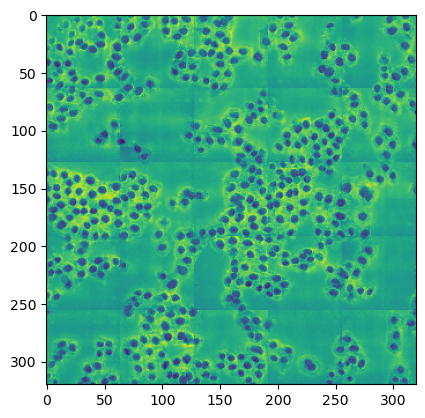

In [10]:
#plt.figure(figsize=(20,20))
plt.imshow(all_features[:,:,0])

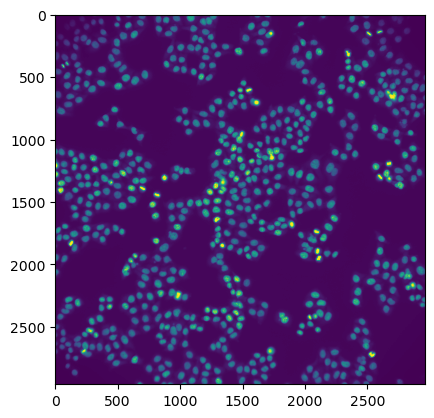

In [11]:
plt.imshow(im)